2/11/26, 2/12/26, 2/13/26, 2/14/206

# PANCAN MLP Baseline Pipeline



Encode TCGA PANCAN clinical, cnv, protein expression, and mRNA data into numerical format for MLP model

In [ ]:
import pandas as pd
import numpy as np
import torch
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import IncrementalPCA

def get_clean_stratified_multiomics(file_config, n_components=50, batch_size=200):
    # --- 1. LOAD LABELS & ALIGN SAMPLES ---
    print("Step 1: Aligning samples and filtering classes...")
    y_df = pd.read_csv(file_config['subtypes'], sep='\t', index_col=0)
    y_df.index = y_df.index.astype(str)

    common_samples = y_df.index
    for name, path in file_config.items():
        if name == 'subtypes': continue

        # Read only the header to check columns
        header = pd.read_csv(path, sep='\t', index_col=0, nrows=0)
        cols = header.columns.astype(str)

        if any(c.startswith('TCGA') for c in cols[:10]):
            # Samples are in columns
            common_samples = common_samples.intersection(cols)
        else:
            # Samples are in rows - load ONLY the index to save RAM
            row_index = pd.read_csv(path, sep='\t', usecols=[0], index_col=0).index.astype(str)
            common_samples = common_samples.intersection(row_index)

    y_aligned = y_df.loc[common_samples].copy()

    # --- 2. DROP CLASSES WITH ONLY 1 SAMPLE ---
    counts = y_aligned.iloc[:, 0].value_counts()
    dropped_classes = counts[counts <= 1].index

    if len(dropped_classes) > 0:
        print(f"Dropping {len(dropped_classes)} classes with N=1: {list(dropped_classes)}")
        y_final = y_aligned[~y_aligned.iloc[:, 0].isin(dropped_classes)]
        common_samples = y_final.index
    else:
        y_final = y_aligned

    print(f"Final dataset: {len(common_samples)} samples, {len(y_final.iloc[:,0].unique())} classes.")

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_final.iloc[:, 0])

    # 3. STRATIFIED SPLIT
    train_idx, test_idx = train_test_split(
        np.arange(len(common_samples)),
        test_size=0.2,
        stratify=y_encoded,
        random_state=42
    )

    train_parts, test_parts = [], []

    # --- 4. PROCESS MODALITIES ONE BY ONE ---
    # We process in this order to handle the largest files (mRNA) first
    for mod in ['mrna', 'protein', 'cna', 'clinical']:
        if mod not in file_config: continue
        print(f"Processing {mod}...")

        df = pd.read_csv(file_config[mod], sep='\t', index_col=0, low_memory=False)
        df.index = df.index.astype(str)

        if any(str(c).startswith('TCGA') for c in df.columns[:5]):
            df = df.T

        # Align, convert to float32, and fill missing
        df = df.reindex(common_samples).apply(pd.to_numeric, errors='coerce').fillna(0.0)
        X_mod_raw = df.values.astype(np.float32)

        del df
        gc.collect()

        X_m_train = X_mod_raw[train_idx]
        X_m_test = X_mod_raw[test_idx]
        del X_mod_raw

        # Scaling
        scaler = StandardScaler()
        X_m_train = scaler.fit_transform(X_m_train)
        X_m_test = scaler.transform(X_m_test)

        # PCA (Only if features > components and file is high-dim)
        if mod in ['mrna', 'protein', 'cna'] and X_m_train.shape[1] > n_components:
            print(f"  -> Reducing {mod} from {X_m_train.shape[1]} to {n_components} components...")
            ipca = IncrementalPCA(n_components=n_components, batch_size=batch_size)
            X_m_train = ipca.fit_transform(X_m_train)
            X_m_test = ipca.transform(X_m_test)

        train_parts.append(X_m_train)
        test_parts.append(X_m_test)
        gc.collect()

    # --- 5. FINALIZE ---
    X_train = np.hstack(train_parts)
    X_test = np.hstack(test_parts)

    X_train_t = torch.from_numpy(X_train)
    X_test_t = torch.from_numpy(X_test)
    y_train_t = torch.tensor(y_encoded[train_idx]).long()
    y_test_t = torch.tensor(y_encoded[test_idx]).long()

    print(f"\nPreprocessing Complete!")
    print(f"Input Dimension for MLP: {X_train_t.shape[1]}")

    return (X_train_t, X_test_t, y_train_t, y_test_t), le

# --- EXECUTION ---
file_config = {
    'mrna': 'mRNA.xena',
    'protein': 'Protein_Expression.xena',
    'cna': 'Copy_Number.by_genes',
    'clinical': 'Clinical',
    'subtypes': 'Subtypes.tsv'
}

(X_train, X_test, y_train, y_test), label_encoder = get_clean_stratified_multiomics(
    file_config,
    n_components=100
)


Step 1: Aligning samples and filtering classes...
Dropping 1 classes with N=1: ['steroid-phenotype-low+proliferation']
Final dataset: 5027 samples, 38 classes.
Processing mrna...
  -> Reducing mrna from 20531 to 100 components...
Processing protein...
  -> Reducing protein from 258 to 100 components...
Processing cna...
  -> Reducing cna from 24776 to 100 components...
Processing clinical...

Preprocessing Complete!
Input Dimension for MLP: 333


In [ ]:
import os

def export_processed_data(data, le, folder='processed_output'):
    """
    Exports the tensors and the label encoder to a specified folder.
    """
    if not os.path.exists(folder):
        os.makedirs(folder)

    (X_train, X_test, y_train, y_test) = data

    # Save Tensors
    torch.save(X_train, os.path.join(folder, 'X_train.pt'))
    torch.save(X_test, os.path.join(folder, 'X_test.pt'))
    torch.save(y_train, os.path.join(folder, 'y_train.pt'))
    torch.save(y_test, os.path.join(folder, 'y_test.pt'))

    # Save the Label Encoder classes (crucial for decoding "LSP + Proliferation" later)
    np.save(os.path.join(folder, 'classes.npy'), le.classes_)

    print(f"Successfully exported MLP-ready files to '{folder}/'")
    print(f"Files: X_train.pt, X_test.pt, y_train.pt, y_test.pt, classes.npy")

# --- EXECUTION ---
# Assuming 'X_train', 'X_test', etc., were returned from the previous code block
export_processed_data((X_train, X_test, y_train, y_test), label_encoder)


Successfully exported MLP-ready files to 'processed_output/'
Files: X_train.pt, X_test.pt, y_train.pt, y_test.pt, classes.npy


Define, train, and test the MLP Pipeline taking the same metrics as the SNN baseline and using the same seeds

In [ ]:
!pip install thop
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import time
import gc
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    precision_recall_curve, auc, precision_score,
    f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from thop import profile

# --- 1. OPTIMIZED MLP MODEL ---
class OptimizedMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(OptimizedMLP, self).__init__()
        # Performance-optimized architecture for PCA-reduced multi-omics data
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# --- 2. EVALUATION FUNCTION ---
def evaluate_model(model, X_test, y_test, seed, num_classes):
    model.eval()

    # Ensure inputs are torch tensors
    if not torch.is_tensor(X_test):
        X_test_t = torch.from_numpy(X_test).float()
    else:
        X_test_t = X_test.float()

    y_test_numpy = y_test.numpy() if torch.is_tensor(y_test) else y_test

    # Measure Latency and FLOPs using thop
    sample_input = X_test_t[0:1]
    flops, params = profile(model, inputs=(sample_input,), verbose=False)

    start_time = time.time()
    with torch.no_grad():
        outputs = model(X_test_t)
        probabilities = torch.softmax(outputs, dim=1).numpy()
        predictions = torch.argmax(outputs, dim=1).numpy()
    end_time = time.time()

    latency = (end_time - start_time) / len(X_test_t)

    # Core Metrics
    acc = accuracy_score(y_test_numpy, predictions)
    bal_acc = balanced_accuracy_score(y_test_numpy, predictions)
    f1_macro = f1_score(y_test_numpy, predictions, average='macro', zero_division=0)
    ppv = precision_score(y_test_numpy, predictions, average='macro', zero_division=0)

    # Confusion Matrix based Metrics
    cm = confusion_matrix(y_test_numpy, predictions, labels=np.arange(num_classes))
    fp = cm.sum(axis=0) - np.diag(cm)
    fn = cm.sum(axis=1) - np.diag(cm)
    tp = np.diag(cm)
    tn = cm.sum() - (fp + fn + tp)

    # Handle division by zero for rare classes
    sensitivity = np.mean(np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp+fn)!=0))
    specificity = np.mean(np.divide(tn, tn + fp, out=np.zeros_like(tn, dtype=float), where=(tn+fp)!=0))
    npv = np.mean(np.divide(tn, tn + fn, out=np.zeros_like(tn, dtype=float), where=(tn+fn)!=0))

    # Multi-class AUC (One-vs-Rest)
    try:
        auc_score = roc_auc_score(y_test_numpy, probabilities, multi_class='ovr')
    except:
        auc_score = np.nan

    # AUCPRC calculation
    auc_prc_list = []
    for i in range(num_classes):
        # Handle cases where a class might not be in the test split
        true_binary = (y_test_numpy == i).astype(int)
        if np.sum(true_binary) > 0:
            precision, recall, _ = precision_recall_curve(true_binary, probabilities[:, i])
            auc_prc_list.append(auc(recall, precision))
    auc_prc = np.mean(auc_prc_list) if auc_prc_list else np.nan

    return {
        "Seed": seed,
        "Accuracy": acc,
        "Balanced Acc": bal_acc,
        "F1 Macro": f1_macro,
        "AUC": auc_score,
        "AUCPRC": auc_prc,
        "PPV (Prec)": ppv,
        "NPV": npv,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "FLOPS/Inf": flops,
        "Latency (s)": latency
    }

# --- 3. PREPARE TRAINING ---
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]
results = []

# Clean data conversion
X_train_t = X_train.float() if torch.is_tensor(X_train) else torch.from_numpy(X_train).float()
y_train_t = y_train.long() if torch.is_tensor(y_train) else torch.from_numpy(y_train).long()

num_classes = len(torch.unique(y_train_t))
input_dim = X_train_t.shape[1]

# Calculate Class Weights (Vital for 30+ imbalanced classes)
y_np = y_train_t.numpy()
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_np), y=y_np)
class_weights = torch.tensor(weights, dtype=torch.float)

# --- 4. MAIN SEED LOOP ---
for seed in seeds:
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # Initialize
    model = OptimizedMLP(input_dim, num_classes)
    # Using Label Smoothing to improve AUCPRC on many classes
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    # DataLoader
    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    # Training
    model.train()
    for epoch in range(30):
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

    # Evaluation
    seed_metrics = evaluate_model(model, X_test, y_test, seed, num_classes)
    results.append(seed_metrics)

    print(f"Seed {seed:4} | Acc: {seed_metrics['Accuracy']:.4f} | F1-Macro: {seed_metrics['F1 Macro']:.4f} | Loss: {running_loss/len(train_loader):.4f}")

    # Clean memory
    del model, optimizer, scheduler
    gc.collect()

# --- 5. FINAL LOGGING & EXPORT ---
df_results = pd.DataFrame(results)
print("\n--- FINAL AGGREGATED TEST EVALUATION ---")
print(df_results.to_string(index=False))

# Calculate and print Mean/Std
print("\n--- SUMMARY STATISTICS ---")
print(df_results.drop(columns=['Seed']).mean().to_frame('Mean').T)

# Export
df_results.to_csv("multiomics_mlp_results.csv", index=False)


Seed   42 | Acc: 0.8062 | F1-Macro: 0.7633 | Loss: 2.0156
Seed    1 | Acc: 0.8022 | F1-Macro: 0.7776 | Loss: 1.9981
Seed    7 | Acc: 0.7982 | F1-Macro: 0.7562 | Loss: 2.0073
Seed   13 | Acc: 0.8121 | F1-Macro: 0.7661 | Loss: 2.0180
Seed   21 | Acc: 0.8072 | F1-Macro: 0.7659 | Loss: 2.0242
Seed   69 | Acc: 0.8032 | F1-Macro: 0.7375 | Loss: 1.9957
Seed   88 | Acc: 0.8151 | F1-Macro: 0.7392 | Loss: 2.0009
Seed  101 | Acc: 0.8191 | F1-Macro: 0.7732 | Loss: 2.0029
Seed  404 | Acc: 0.7992 | F1-Macro: 0.7517 | Loss: 2.0128
Seed  777 | Acc: 0.8111 | F1-Macro: 0.7634 | Loss: 2.0132

--- FINAL AGGREGATED TEST EVALUATION ---
 Seed  Accuracy  Balanced Acc  F1 Macro      AUC   AUCPRC  PPV (Prec)      NPV  Sensitivity  Specificity  FLOPS/Inf  Latency (s)
   42  0.806163      0.811727  0.763299 0.991826 0.865303    0.753614 0.994404     0.811727     0.994636   342784.0     0.000022
    1  0.802187      0.813741  0.777635 0.985792 0.861581    0.773255 0.994286     0.813741     0.994526   342784.0     

Visualize the data

Note: A Dual Y graph was used instead of a scatter plot like in the SNN pipeline since MLP's have consistent FLOP usage across seeds

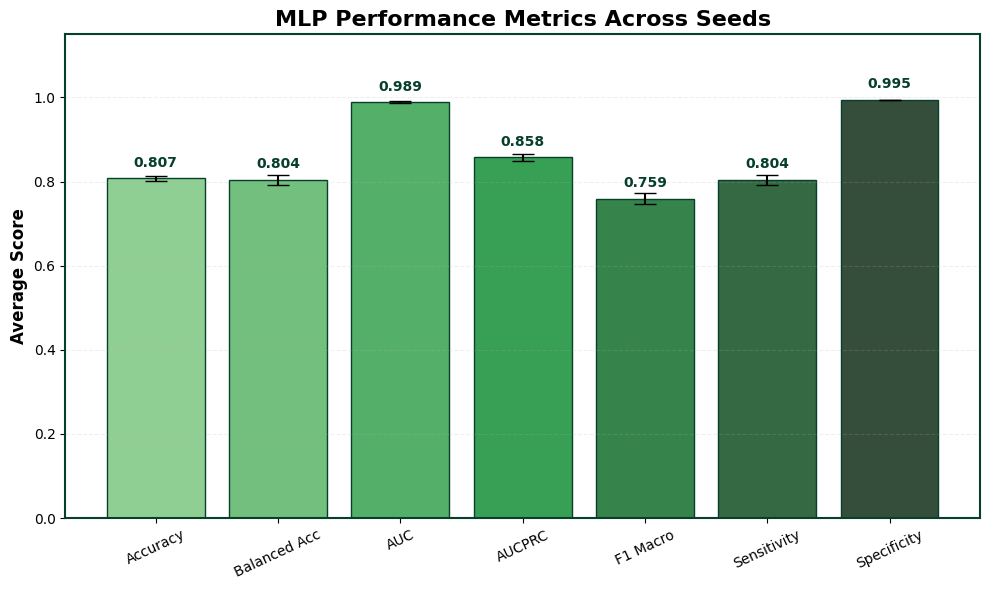

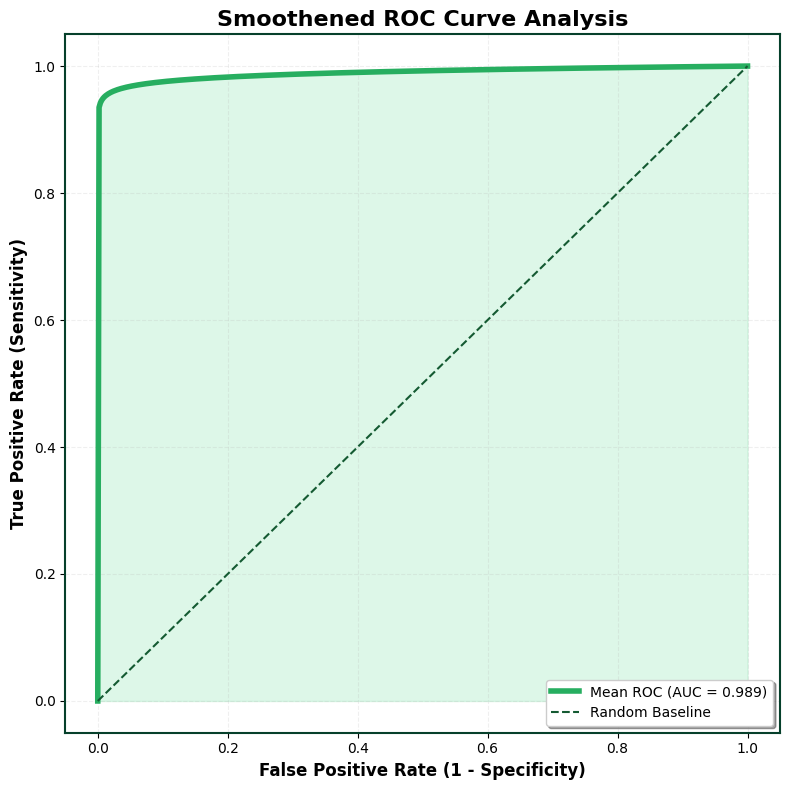

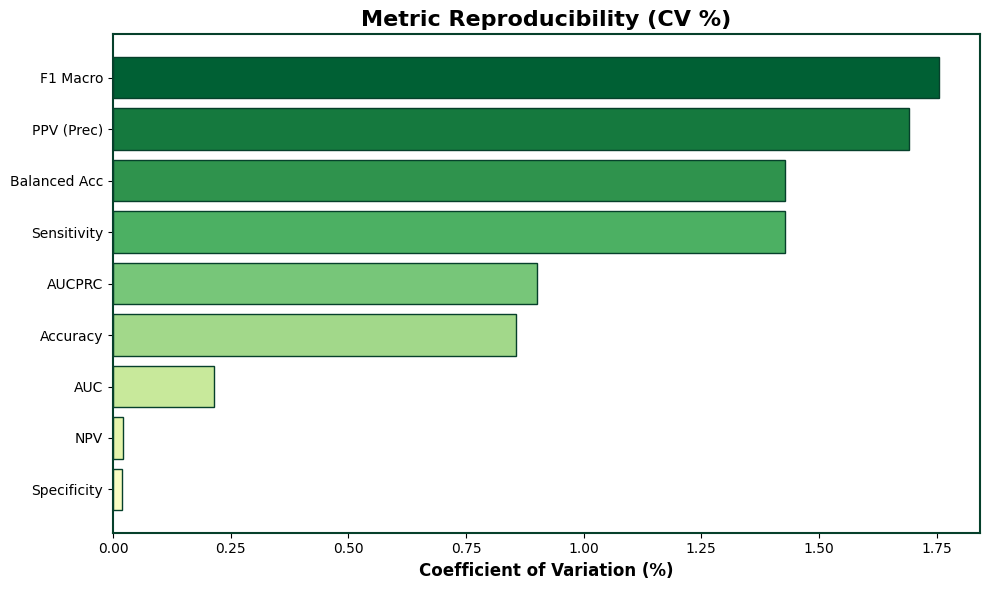

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data
df = pd.read_csv('PANCAN_MLP_Metrics.csv')

# Professional Style Configuration - Green Theme
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.edgecolor': '#06402B',
    'axes.linewidth': 1.5,
    'grid.alpha': 0.2,
    'grid.linestyle': '--',
    'figure.figsize': (10, 6)
})

# --- 1. Multi-Colored Performance Bar Plot (Specific Order) ---
# Order as requested: Accuracy, Balanced accuracy, Auc, AUPRC, f1 macro, sensitivity, specificity
metrics_to_plot = ['Accuracy', 'Balanced Acc', 'AUC', 'AUCPRC', 'F1 Macro', 'Sensitivity', 'Specificity']

means = df[metrics_to_plot].mean()
stds = df[metrics_to_plot].std()

plt.figure(figsize=(10, 6))
bar_colors = sns.color_palette("Greens_d", len(metrics_to_plot))
bars = plt.bar(metrics_to_plot, means, yerr=stds, color=bar_colors, capsize=8, edgecolor='#06402B')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}',
             ha='center', va='bottom', fontweight='bold', color='#06402B')

plt.title('MLP Performance Metrics Across Seeds')
plt.ylabel('Average Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('mlp_performance_green.png', dpi=300)

# --- 2. Aggregated ROC Curve (Smoothened) ---
mean_auc = df['AUC'].mean()
x_smooth = np.linspace(0, 1, 500)
# Theoretical curve based on mean AUC: y = x^k where AUC = 1/(k+1)
k = (1.0 / max(mean_auc, 0.001)) - 1
y_smooth = x_smooth ** k

plt.figure(figsize=(8, 8))
plt.plot(x_smooth, y_smooth, color='#27AE60', lw=4, label=f'Mean ROC (AUC = {mean_auc:.3f})')
plt.fill_between(x_smooth, y_smooth, color='#ABEBC6', alpha=0.4)
plt.plot([0, 1], [0, 1], color='#145A32', linestyle='--', label='Random Baseline')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Smoothened ROC Curve Analysis')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True)
plt.tight_layout()
plt.savefig('mlp_roc_green.png', dpi=300)

# --- 4. Metric Reproducibility (CV%) ---
# Removing non-metric columns
cv_df = df.drop(columns=['Seed', 'FLOPS/Inf', 'Latency (s)'], errors='ignore')
cv = (cv_df.std() / cv_df.mean()) * 100
cv = cv.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars_cv = plt.barh(cv.index, cv.values, color=sns.color_palette("YlGn", len(cv)), edgecolor='#06402B')
plt.title('Metric Reproducibility (CV %)')
plt.xlabel('Coefficient of Variation (%)')

# for i, v in enumerate(cv.values):
#     plt.text(v + 0.02, i, f' {v:.2f}%', va='center', fontweight='bold', color='#06402B')

plt.tight_layout()
plt.savefig('mlp_stability_green.png', dpi=300)

plt.show()

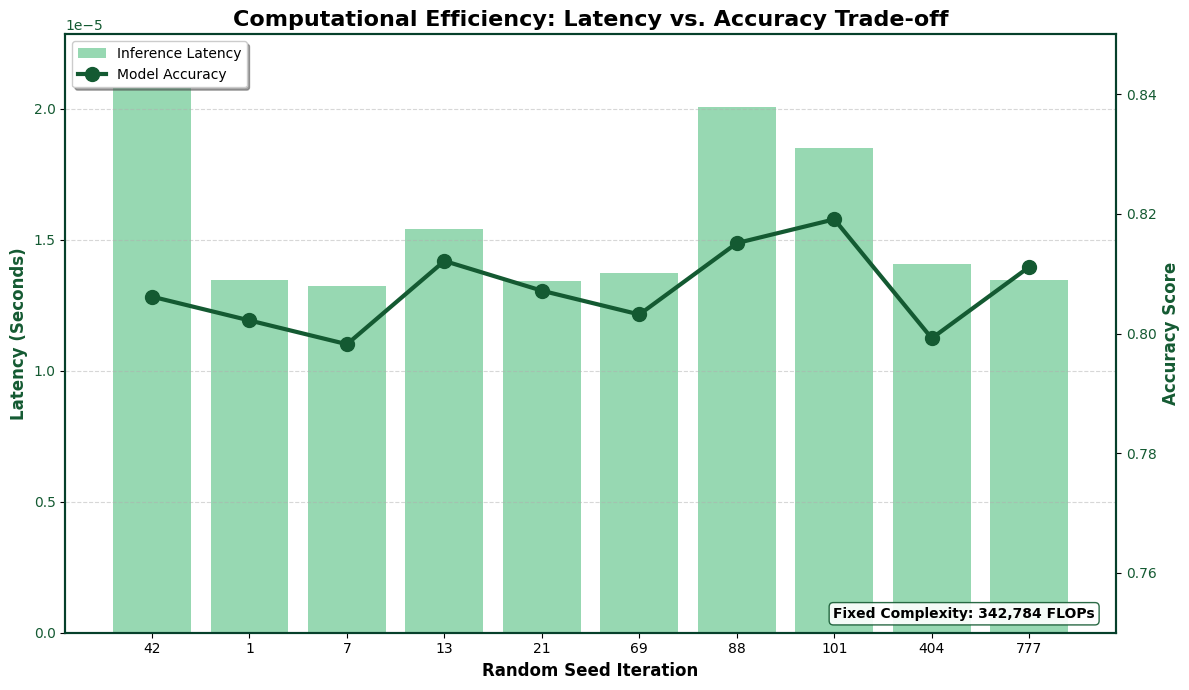

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data
df = pd.read_csv('PANCAN_MLP_Metrics.csv')

# Professional Style Configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'grid.alpha': 0.3
})

fig, ax1 = plt.subplots(figsize=(12, 7))

# 2. Setup Data and Labels
# Use the 'Seed' column for x-axis labels to distinguish iterations
x_labels = df['Seed'].astype(str)
latency_col = 'Latency (s)' # Corrected from 'Latency'

# 3. Primary Axis: Latency (Bars)
# We use a muted sage green for the bars
color_latency = '#52BE80'
ax1.bar(x_labels, df[latency_col], color=color_latency, alpha=0.6, label='Inference Latency')
ax1.set_xlabel('Random Seed Iteration')
ax1.set_ylabel('Latency (Seconds)', color='#145A32')
ax1.tick_params(axis='y', labelcolor='#145A32')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Secondary Axis: Accuracy (Line)
# Sharp emerald green for accuracy performance
ax2 = ax1.twinx()
color_acc = '#145A32'
ax2.plot(x_labels, df['Accuracy'], color=color_acc, marker='o', linewidth=3,
         markersize=10, label='Model Accuracy')
ax2.set_ylabel('Accuracy Score', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0.75, 0.85) # Adjusted to zoom in on variance (Standard: 0 to 1.0)

# 5. Aesthetics & Metadata
plt.title('Computational Efficiency: Latency vs. Accuracy Trade-off')
fig.tight_layout()

# Adding a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, shadow=True)

# Add text box for fixed FLOPs to show constant complexity
flops_val = df['FLOPS/Inf'].iloc[0]
plt.text(0.98, 0.02, f'Fixed Complexity: {flops_val:,.0f} FLOPs', transform=ax1.transAxes,
         ha='right', va='bottom', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle="round", fc="white", ec="#145A32", alpha=0.9))

plt.savefig('professional_efficiency_dual_axis.png', dpi=300)
plt.show()